### **Celda 1: Importaciones y configuración inicial**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import scipy.stats as stats
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('rent_features.csv')
print(f"Dimensiones originales: {df.shape}")

df['latitud'] = pd.to_numeric(df['latitud'], errors='coerce')
df['longitud'] = pd.to_numeric(df['longitud'], errors='coerce')
df = df.dropna(subset=['latitud', 'longitud'])
df = df[(df['latitud'] != 0) & (df['longitud'] != 0)]
print(f"Filas después de limpiar ubicación: {len(df)}")

print(f"Nulos restantes: {df.isnull().sum().sum()}")

Dimensiones originales: (3097, 16)
Filas después de limpiar ubicación: 3097
Nulos restantes: 0


### **Celda 2: Preprocesamiento y Entrenamiento**

In [2]:
strat_col = df['tipo_propiedad_original'].copy()

columnas_modelo = [
    'm2_terreno', 'm2_construido', 'banos', 'medios_banos',
    'estacionamientos', 'antiguedad',
    'amen_Alberca', 'amen_Cocina integral', 'amen_Amueblado', 'amen_Elevador',
    'amen_Cuartos de servicio', 'tipo_propiedad_departamento', 'latitud', 'longitud'
]

X = df[columnas_modelo].copy()
y = df['precio']

y_log = np.log1p(y)

indices = np.arange(len(X))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=strat_col
)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train_log = y_log.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")

Entrenamiento: 2477 registros
Prueba: 620 registros


### **Celda 3: Regresión Lineal (con Pipeline y escalado)**

In [3]:
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

cv_scores_lr = cross_val_score(pipeline_lr, X_train, y_train_log,
                                cv=5, scoring='neg_root_mean_squared_error')
print(f"Regresión Lineal - RMSE CV (log): {-cv_scores_lr.mean():.4f} +/- {cv_scores_lr.std():.4f}")

pipeline_lr.fit(X_train, y_train_log)
y_pred_log_lr = pipeline_lr.predict(X_test)
y_pred_lr = np.expm1(y_pred_log_lr)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100

print("\n--- Evaluación Regresión Lineal ---")
print(f"R²: {r2_lr:.4f}")
print(f"MAE: ${mae_lr:,.2f}")
print(f"RMSE: ${rmse_lr:,.2f}")
print(f"MAPE: {mape_lr:.2f}%")

Regresión Lineal - RMSE CV (log): 0.4550 +/- 0.0160

--- Evaluación Regresión Lineal ---
R²: -13.0382
MAE: $24,143.44
RMSE: $166,062.64
MAPE: 42.99%


### **Celda 4: Random Forest (con los mejores parámetros de la justificación)**

In [4]:
# Mejores parámetros encontrados en la justificación:
# {'max_depth': 12, 'max_features': 0.7, 'min_samples_leaf': 2, 
#  'min_samples_split': 5, 'n_estimators': 250}

best_rf = RandomForestRegressor(
    n_estimators=250,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)

# Entrenar
best_rf.fit(X_train, y_train_log)

# Predicción en test
y_pred_log_rf = best_rf.predict(X_test)
y_pred_rf = np.expm1(y_pred_log_rf)

# Métricas
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print("\n--- Evaluación Random Forest ---")
print(f"R²: {r2_rf:.4f}")
print(f"MAE: ${mae_rf:,.2f}")
print(f"RMSE: ${rmse_rf:,.2f}")
print(f"MAPE: {mape_rf:.2f}%")

# Importancia de variables
importancias_rf = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': best_rf.feature_importances_
}).sort_values('Importancia', ascending=False)
print("\n--- Top 10 variables más importantes (RF) ---")
print(importancias_rf.head(10))


--- Evaluación Random Forest ---
R²: 0.7626
MAE: $11,225.98
RMSE: $21,596.68
MAPE: 25.12%

--- Top 10 variables más importantes (RF) ---
                       Variable  Importancia
1                 m2_construido     0.491990
2                         banos     0.095351
13                     longitud     0.084262
12                      latitud     0.082191
0                    m2_terreno     0.070808
11  tipo_propiedad_departamento     0.041628
4              estacionamientos     0.039003
9                 amen_Elevador     0.030806
5                    antiguedad     0.022700
10     amen_Cuartos de servicio     0.011657


### **Celda 5: XGBoost (con regularización y parámetros óptimos)**

In [5]:
# Mejores parámetros encontrados en la justificación:
# {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 6, 
#  'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 10, 'subsample': 0.8}

best_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=10,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# Entrenar
best_xgb.fit(X_train, y_train_log)

# Predicción en test
y_pred_log_xgb = best_xgb.predict(X_test)
y_pred_xgb = np.expm1(y_pred_log_xgb)

# Métricas
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print("\n--- Evaluación XGBoost ---")
print(f"R²: {r2_xgb:.4f}")
print(f"MAE: ${mae_xgb:,.2f}")
print(f"RMSE: ${rmse_xgb:,.2f}")
print(f"MAPE: {mape_xgb:.2f}%")

# Importancia de variables
importancias_xgb = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': best_xgb.feature_importances_
}).sort_values('Importancia', ascending=False)
print("\n--- Top 10 variables más importantes (XGBoost) ---")
print(importancias_xgb.head(10))


--- Evaluación XGBoost ---
R²: 0.8160
MAE: $9,805.86
RMSE: $19,012.89
MAPE: 21.27%

--- Top 10 variables más importantes (XGBoost) ---
                       Variable  Importancia
11  tipo_propiedad_departamento     0.278920
1                 m2_construido     0.192240
2                         banos     0.114792
10     amen_Cuartos de servicio     0.078366
9                 amen_Elevador     0.074645
0                    m2_terreno     0.052802
12                      latitud     0.038612
6                  amen_Alberca     0.035433
13                     longitud     0.035201
4              estacionamientos     0.030390


### **Celda 6: Comparativa de resultados y elección del mejor modelo**

In [6]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest', 'XGBoost'],
    'R²': [r2_lr, r2_rf, r2_xgb],
    'MAE (MXN)': [mae_lr, mae_rf, mae_xgb],
    'RMSE (MXN)': [rmse_lr, rmse_rf, rmse_xgb],
    'MAPE (%)': [mape_lr, mape_rf, mape_xgb]
})

print("\n" + "="*70)
print("COMPARATIVA DE MODELOS (Escala Original)")
print("="*70)
print(resultados.to_string(index=False, float_format=lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) and abs(x) > 100 else f"{x:.4f}"))

mejor_modelo = 'XGBoost'
print(f"\nModelo seleccionado para producción: {mejor_modelo}")
print(f"   - R²: {r2_xgb:.4f}")
print(f"   - MAE: ${mae_xgb:,.2f}")
print(f"   - RMSE: ${rmse_xgb:,.2f}")
print(f"   - MAPE: {mape_xgb:.2f}%")


COMPARATIVA DE MODELOS (Escala Original)
          Modelo       R²  MAE (MXN)  RMSE (MXN)  MAPE (%)
Regresión Lineal -13.0382  24,143.44  166,062.64   42.9861
   Random Forest   0.7626  11,225.98   21,596.68   25.1230
         XGBoost   0.8160   9,805.86   19,012.89   21.2690

Modelo seleccionado para producción: XGBoost
   - R²: 0.8160
   - MAE: $9,805.86
   - RMSE: $19,012.89
   - MAPE: 21.27%


### **Celda 7: Gráfico de Predicción vs Real (para el mejor modelo)**

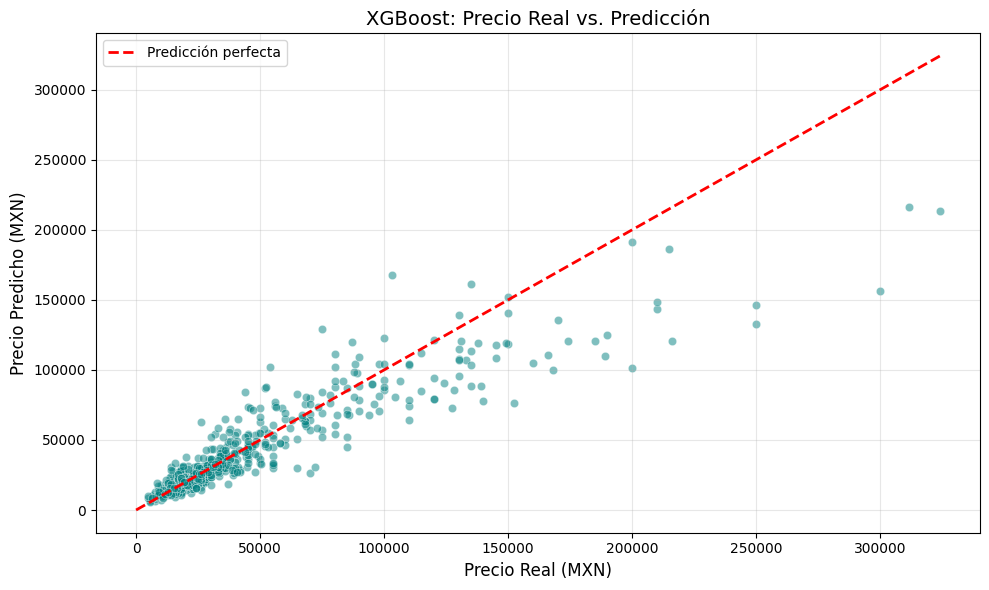

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.5, color='teal')
max_val = max(y_test.max(), y_pred_xgb.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Predicción perfecta')
plt.title(f'XGBoost: Precio Real vs. Predicción', fontsize=14)
plt.xlabel('Precio Real (MXN)', fontsize=12)
plt.ylabel('Precio Predicho (MXN)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **Celda 8: Análisis de Residuos (para diagnóstico del mejor modelo)**

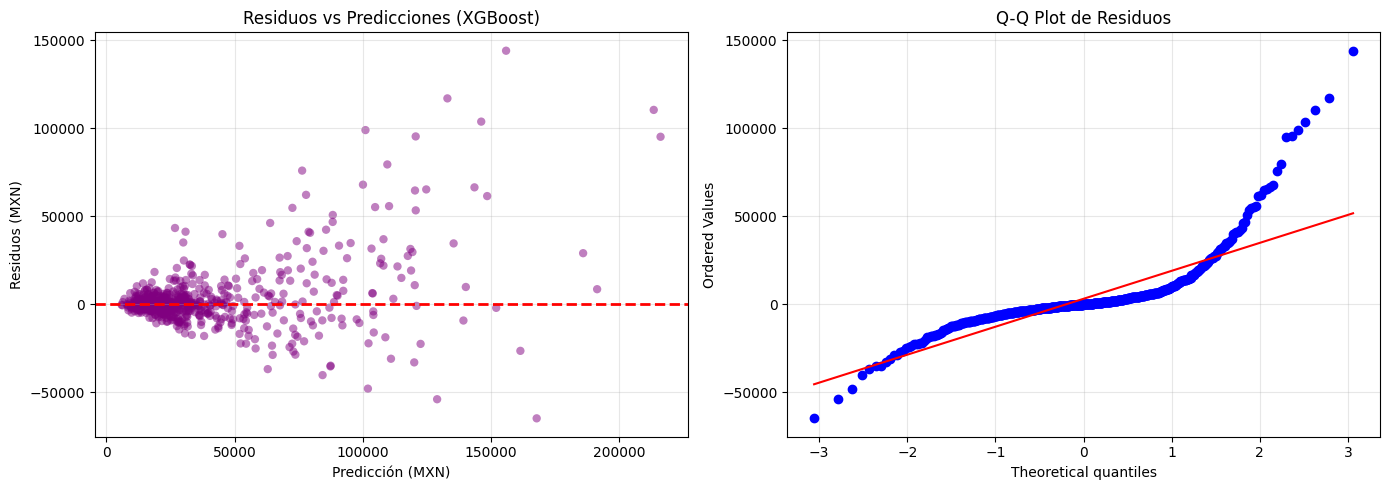


--- Estadísticos de Residuos ---
Media: $3013.94
Desviación estándar: $18787.64
Mínimo: $-64947.41
Máximo: $143997.31
Percentil 1%: $-34661.66
Percentil 99%: $92105.24


In [8]:
residuos = y_test - y_pred_xgb

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_xgb, residuos, alpha=0.5, color='purple', edgecolor='none')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuos vs Predicciones (XGBoost)', fontsize=12)
axes[0].set_xlabel('Predicción (MXN)')
axes[0].set_ylabel('Residuos (MXN)')
axes[0].grid(alpha=0.3)

stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot de Residuos', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Estadísticos de Residuos ---")
print(f"Media: ${residuos.mean():.2f}")
print(f"Desviación estándar: ${residuos.std():.2f}")
print(f"Mínimo: ${residuos.min():.2f}")
print(f"Máximo: ${residuos.max():.2f}")
print(f"Percentil 1%: ${residuos.quantile(0.01):.2f}")
print(f"Percentil 99%: ${residuos.quantile(0.99):.2f}")

### **Celda 9: Guardar el modelo final (XGBoost)**

In [31]:
joblib.dump(best_xgb, 'modelo_renta_xgboost_final.pkl')
print("Modelo guardado como 'modelo_renta_xgboost_final.pkl'")

import json
with open('columnas_modelo.json', 'w') as f:
    json.dump(columnas_modelo, f)
print("Lista de columnas guardada como 'columnas_modelo.json'")

Modelo guardado como 'modelo_renta_xgboost_final.pkl'
Lista de columnas guardada como 'columnas_modelo.json'


### **Celda 10: Función de predicción y ejemplo de uso**

In [9]:
def predecir_renta(modelo, datos):
    """
    datos: dict con las variables requeridas (mismas claves que columnas_modelo).
    Retorna el precio estimado en MXN.
    """
    entrada = pd.DataFrame([datos])
    entrada = entrada.reindex(columns=columnas_modelo, fill_value=0)
    pred_log = modelo.predict(entrada)
    return np.expm1(pred_log)[0]

propiedad_ejemplo = {
    'm2_terreno': 65,
    'm2_construido': 65,
    'banos': 2,
    'medios_banos': 0,
    'estacionamientos': 0,
    'antiguedad': 5,
    'amen_Alberca': 0,
    'amen_Cocina integral': 1,
    'amen_Amueblado': 0,
    'amen_Elevador': 1,
    'amen_Cuartos de servicio': 1,
    'tipo_propiedad_departamento': 1,
    'latitud': 19.4055,
    'longitud': -99.1848
}

precio_estimado = predecir_renta(best_xgb, propiedad_ejemplo)
print("\n--- Ejemplo de predicción ---")
print(f"Renta estimada para el departamento: ${precio_estimado:,.2f}")

pred_log = best_xgb.predict(pd.DataFrame([propiedad_ejemplo]).reindex(columns=columnas_modelo, fill_value=0))
print(f"(Log) Predicción en escala log: {pred_log[0]:.4f}")


--- Ejemplo de predicción ---
Renta estimada para el departamento: $25,399.08
(Log) Predicción en escala log: 10.1425
